URL: https://www.kaggle.com/datasets/hansespinosa2/40000-video-game-midi-files?select=vg_console_song_credits.csv

Environment Preparation

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, DoubleType, StringType, IntegerType

In [ ]:
spark = SparkSession.builder.appName("VGMusicAnalysis").getOrCreate()

In [ ]:
schema = StructType([
    StructField("url", StringType(), True),
    StructField("song_file", StringType(), True),
    StructField("song_name", StringType(), True),
    StructField("Credit", StringType(), True),
    StructField("index", IntegerType(), True),
    StructField("game", StringType(), True),
    StructField("company", StringType(), True),
    StructField("console", StringType(), True)
])

In [ ]:
df = spark.read.csv('/content/vg_console_song_credits.csv', sep=",", schema=schema, header=True, multiLine=True, mode='DROPMALFORMED')
df.show()
df.count()

+--------------------+--------------------+--------------------+--------------------+-----+--------------------+-------+-------+
|                 url|           song_file|           song_name|              Credit|index|                game|company|console|
+--------------------+--------------------+--------------------+--------------------+-----+--------------------+-------+-------+
|https://www.vgmus...|      kittytheme.mid|       Kitty's Theme|           G-Han\n\n|24818|Montana Jones (Ja...|    3do|    3do|
|https://www.vgmus...|         Rest_MJ.mid|"Overworld Theme ...| Guan van Zoggel\n\n|24819|Montana Jones (Ja...|    3do|    3do|
|https://www.vgmus...|return_the_stolen...|Return The Stolen...|          DoKoCo\n\n|24820|Montana Jones (Ja...|    3do|    3do|
|https://www.vgmus...|          urquan.mid|    Ur-Quan Kzer-Za | Kirill Podzorov\n\n|24823|      Star Control 2|    3do|    3do|
|https://www.vgmus...|            ken4.mid|                 Ken|         lion589\n\n|24826|Super 

24905

DataSet Cleaning

In [ ]:
from pyspark.sql.functions import regexp_replace

df = df.withColumn("Credit", regexp_replace(df["Credit"], "\\n\\n", ""))
df.show()

+--------------------+--------------------+--------------------+-------------------+-----+--------------------+-------+-------+
|                 url|           song_file|           song_name|             Credit|index|                game|company|console|
+--------------------+--------------------+--------------------+-------------------+-----+--------------------+-------+-------+
|https://www.vgmus...|      kittytheme.mid|       Kitty's Theme|              G-Han|24818|Montana Jones (Ja...|    3do|    3do|
|https://www.vgmus...|         Rest_MJ.mid|"Overworld Theme ...|    Guan van Zoggel|24819|Montana Jones (Ja...|    3do|    3do|
|https://www.vgmus...|return_the_stolen...|Return The Stolen...|             DoKoCo|24820|Montana Jones (Ja...|    3do|    3do|
|https://www.vgmus...|          urquan.mid|    Ur-Quan Kzer-Za |    Kirill Podzorov|24823|      Star Control 2|    3do|    3do|
|https://www.vgmus...|            ken4.mid|                 Ken|            lion589|24826|Super Street F

In [ ]:
from pyspark.sql.functions import col, count

remaining_duplicates = df.groupBy('song_name', 'game') \
                        .agg(count(col('*')).alias('count')) \
                        .filter(col('count') > 1) \
                        .orderBy(col('count').desc())

print("Remaining duplicates after dropDuplicates:")
remaining_duplicates.show(truncate=False)

print(f"Final DataFrame count: {df.count()}")

Remaining duplicates after dropDuplicates:
+--------------------------------------------+-------------------------------+-----+
|song_name                                   |game                           |count|
+--------------------------------------------+-------------------------------+-----+
|Turks' Theme                                |Final Fantasy 7                |3    |
|Mt. Pyre                                    |Pokémon (Ruby, Sapphire)       |3    |
|Level Clear                                 |Q-bert                         |3    |
|Scrap Brain Zone                            |Sonic the Hedgehog             |3    |
|Title Screen                                |Batman Returns                 |3    |
|Title Screen                                |Double Dragon                  |3    |
|Labyrinth Zone                              |Sonic the Hedgehog             |3    |
|Green Hill Zone                             |Sonic the Hedgehog             |3    |
|Visitor Center       

In [ ]:
from pyspark.sql.functions import regexp_replace, lower, trim, col

df = df.withColumn("normalized_song_name",
                   trim(
                       regexp_replace(
                           lower(
                               regexp_replace(col('song_name'), '^"+|"+$', '')
                           ),
                           '\\s*\\([^)]*\\)\\s*$', ''
                       )
                   )
                  )
df.show(truncate=False)

+-------------------------------------------------------------------------------------+---------------------------------------+-----------------------------------+-------------------+-----+-----------------------------+-------+-------+------------------------+
|url                                                                                  |song_file                              |song_name                          |Credit             |index|game                         |company|console|normalized_song_name    |
+-------------------------------------------------------------------------------------+---------------------------------------+-----------------------------------+-------------------+-----+-----------------------------+-------+-------+------------------------+
|https://www.vgmusic.com/music/console/3do/3do/kittytheme.mid                         |kittytheme.mid                         |Kitty's Theme                      |G-Han              |24818|Montana Jones (Japan)       

In [ ]:
original_count = df.count()
df = df.dropDuplicates(['normalized_song_name', 'game'])
print(f"Original DataFrame count: {original_count}")
print(f"DataFrame count after removing duplicates based on normalized_song_name and game: {df.count()}")

Original DataFrame count: 24905
DataFrame count after removing duplicates based on normalized_song_name and game: 17379


In [ ]:
from pyspark.sql.functions import col, count

remaining_duplicates_after_final_dedup = df.groupBy('normalized_song_name', 'game') \
                                        .agg(count(col('*')).alias('count')) \
                                        .filter(col('count') > 1) \
                                        .orderBy(col('count').desc())

print("Remaining duplicates after final deduplication:")
remaining_duplicates_after_final_dedup.show(truncate=False)

Remaining duplicates after final deduplication:
+--------------------+----+-----+
|normalized_song_name|game|count|
+--------------------+----+-----+
+--------------------+----+-----+



In [ ]:
df = df.filter(~df.song_name.contains("Remix"))
df.show()
df.count()

+--------------------+--------------------+--------------------+-------------------+-----+--------------------+--------+---------+--------------------+
|                 url|           song_file|           song_name|             Credit|index|                game| company|  console|normalized_song_name|
+--------------------+--------------------+--------------------+-------------------+-----+--------------------+--------+---------+--------------------+
|https://www.vgmus...|LegendofHeroes4_L...|"# 06 - ""Leaving...|            MaliceX|21403|  Legend of Heroes 4|     nec|     tg16|# 06 - ""leaving ...|
|https://www.vgmus...|LegendofHeroes4_P...|# 36 - Parting Re...|            MaliceX|21407|  Legend of Heroes 4|     nec|     tg16|# 36 - parting re...|
|https://www.vgmus...|T_RivieraTPL_AndT...|"""...And Time Pa...|            Tsu Ryu|19855|Riviera: The Prom...|    sony|      psp|  ...and time passes|
|https://www.vgmus...|      rbs-chrsel.mid|  0B - Select Player|           Stockman|3085

16923

In [ ]:
df = df.filter(~df.song_name.contains("remix"))
df.show()
df.count()

+--------------------+--------------------+--------------------+-------------------+-----+--------------------+--------+---------+--------------------+
|                 url|           song_file|           song_name|             Credit|index|                game| company|  console|normalized_song_name|
+--------------------+--------------------+--------------------+-------------------+-----+--------------------+--------+---------+--------------------+
|https://www.vgmus...|LegendofHeroes4_L...|"# 06 - ""Leaving...|            MaliceX|21403|  Legend of Heroes 4|     nec|     tg16|# 06 - ""leaving ...|
|https://www.vgmus...|LegendofHeroes4_P...|# 36 - Parting Re...|            MaliceX|21407|  Legend of Heroes 4|     nec|     tg16|# 36 - parting re...|
|https://www.vgmus...|T_RivieraTPL_AndT...|"""...And Time Pa...|            Tsu Ryu|19855|Riviera: The Prom...|    sony|      psp|  ...and time passes|
|https://www.vgmus...|      rbs-chrsel.mid|  0B - Select Player|           Stockman|3085

16923

In [ ]:
df = df.filter(~df.song_name.contains("Arrange"))
df.show()
df.count()

+--------------------+--------------------+--------------------+-------------------+-----+--------------------+--------+---------+--------------------+
|                 url|           song_file|           song_name|             Credit|index|                game| company|  console|normalized_song_name|
+--------------------+--------------------+--------------------+-------------------+-----+--------------------+--------+---------+--------------------+
|https://www.vgmus...|LegendofHeroes4_L...|"# 06 - ""Leaving...|            MaliceX|21403|  Legend of Heroes 4|     nec|     tg16|# 06 - ""leaving ...|
|https://www.vgmus...|LegendofHeroes4_P...|# 36 - Parting Re...|            MaliceX|21407|  Legend of Heroes 4|     nec|     tg16|# 36 - parting re...|
|https://www.vgmus...|T_RivieraTPL_AndT...|"""...And Time Pa...|            Tsu Ryu|19855|Riviera: The Prom...|    sony|      psp|  ...and time passes|
|https://www.vgmus...|      rbs-chrsel.mid|  0B - Select Player|           Stockman|3085

16684

In [ ]:
df = df.filter(~df.song_name.contains("Arranged") & ~df.song_name.contains("arranged"))
df.show()
df.count()

+--------------------+--------------------+--------------------+-------------------+-----+--------------------+--------+---------+--------------------+
|                 url|           song_file|           song_name|             Credit|index|                game| company|  console|normalized_song_name|
+--------------------+--------------------+--------------------+-------------------+-----+--------------------+--------+---------+--------------------+
|https://www.vgmus...|LegendofHeroes4_L...|"# 06 - ""Leaving...|            MaliceX|21403|  Legend of Heroes 4|     nec|     tg16|# 06 - ""leaving ...|
|https://www.vgmus...|LegendofHeroes4_P...|# 36 - Parting Re...|            MaliceX|21407|  Legend of Heroes 4|     nec|     tg16|# 36 - parting re...|
|https://www.vgmus...|T_RivieraTPL_AndT...|"""...And Time Pa...|            Tsu Ryu|19855|Riviera: The Prom...|    sony|      psp|  ...and time passes|
|https://www.vgmus...|      rbs-chrsel.mid|  0B - Select Player|           Stockman|3085

16681

Data Sampling

In [ ]:
from pyspark.sql.functions import regexp_like, lit

### Aquatic Songs Data Set

# Include Data
aqua_include_conditions = (regexp_like(df.song_name, lit("Water")) |
                      regexp_like(df.song_name, lit("water")) |
                      regexp_like(df.song_name, lit("Surfing")) |
                      regexp_like(df.song_name, lit("River")) |
                      regexp_like(df.song_name, lit("Aqua")) |
                      regexp_like(df.song_name, lit("Lake")) |
                      regexp_like(df.song_name, lit("Labyrinth Zone")))

# Exclude Data
aqua_exclude_conditions = (df.song_name.contains("Team Magma") |
                      df.song_name.contains("Bug") |
                      df.song_name.contains("Team Aqua") |
                      df.song_name.contains("Magma/Aqua"))

# Combine Data
aquatic_songs = df.filter(aqua_include_conditions & ~aqua_exclude_conditions)


aquatic_songs.show()
aquatic_songs.count()

+--------------------+--------------------+--------------------+----------------+-----+--------------------+--------+---------+--------------------+
|                 url|           song_file|           song_name|          Credit|index|                game| company|  console|normalized_song_name|
+--------------------+--------------------+--------------------+----------------+-----+--------------------+--------+---------+--------------------+
|https://www.vgmus...|AltanticaAquatica...|Altantica/Aquatic...|    Rapidkirby3k|30157|Need For Speed 3:...|    sony|      ps1|altantica/aquatic...|
|https://www.vgmus...|Golgo_13_Top_Secr...|           Aqua Base|Jedi Questmaster|12206|Golgo 13: Top Sec...|nintendo|      nes|           aqua base|
|https://www.vgmus...|        gra3ills.mid|       Aqua Illusion|                |19858|         Gradius III|nintendo|     snes|       aqua illusion|
|https://www.vgmus...|sc-AquaPlanetZone...|    Aqua Planet Zone|   TurquoiseStar|10342|         Sonic Chao

151

In [ ]:
### Forest Songs Data Set

# Include Data
forest_include_conditions = (regexp_like(df.song_name, lit("Forest")) |
                      regexp_like(df.song_name, lit("Woods")))

# Exclude Data
forest_exclude_conditions = (df.song_name.contains("Beta"))

# Combine Data
forest_songs = df.filter(forest_include_conditions & ~forest_exclude_conditions)


forest_songs.show(200, truncate=False)
forest_songs.count()

+-----------------------------------------------------------------------------------------------------------+--------------------------------------------------------+-----------------------------------------------------+-----------------------------+-----+-------------------------------------------------------+---------+---------+-----------------------------------------------+
|url                                                                                                        |song_file                                               |song_name                                            |Credit                       |index|game                                                   |company  |console  |normalized_song_name                           |
+-----------------------------------------------------------------------------------------------------------+--------------------------------------------------------+-----------------------------------------------------+------------------

144

In [ ]:
### Jungle Songs Data Set

# Include Data
jgl_include_conditions = (regexp_like(df.song_name, lit("Jungle")) |
                      regexp_like(df.song_name, lit("jungle")))

# Exclude Data
jgl_exclude_conditions = (df.song_name.contains("Concrete"))

# Combine Data
jungle_songs = df.filter(jgl_include_conditions & ~jgl_exclude_conditions)


jungle_songs.show(200, truncate=False)
jungle_songs.count()

+--------------------------------------------------------------------------------------------------------------+----------------------------------------------------------+-------------------------------------+------------------------+-----+-----------------------------------------+--------+--------+---------------------------------+
|url                                                                                                           |song_file                                                 |song_name                            |Credit                  |index|game                                     |company |console |normalized_song_name             |
+--------------------------------------------------------------------------------------------------------------+----------------------------------------------------------+-------------------------------------+------------------------+-----+-----------------------------------------+--------+--------+------------------------------

36

In [ ]:
### Ice Songs Data Set

# Include Data
ice_include_conditions = (regexp_like(df.song_name, lit("Ice")) |
                      regexp_like(df.song_name, lit("Snow")) |
                      regexp_like(df.song_name, lit("Winter")) |
                      regexp_like(df.song_name, lit("Cold")) |
                      regexp_like(df.song_name, lit("Freeze")) |
                      regexp_like(df.song_name, lit("Frost")) |
                      regexp_like(df.song_name, lit("Northern Hemispheres")))

# Exclude Data
ice_exclude_conditions = (df.song_name.contains("Joker"))

# Combine Data
ice_songs = df.filter(ice_include_conditions & ~ice_exclude_conditions)


ice_songs.show(200, truncate=False)
ice_songs.count()

+------------------------------------------------------------------------------------------------------+---------------------------------------------------+-------------------------------------------------------------------------------+-----------------------------+-----+----------------------------------------+---------+---------+------------------------------------------------------------------------+
|url                                                                                                   |song_file                                          |song_name                                                                      |Credit                       |index|game                                    |company  |console  |normalized_song_name                                                    |
+------------------------------------------------------------------------------------------------------+---------------------------------------------------+------------------------------

155

In [ ]:
### Beach Songs Data Set

# Include Data
bch_include_conditions = (regexp_like(df.song_name, lit("Beach")) |
                      regexp_like(df.song_name, lit("Delfino")) |
                      regexp_like(df.song_name, lit("Bianco Hills")) |
                      regexp_like(df.song_name, lit("Shore")))


# Combine Data
beach_songs = df.filter(bch_include_conditions)


beach_songs.show(200, truncate=False)
beach_songs.count()

+-------------------------------------------------------------------------------------------+--------------------------------------+------------------------------------+------------------------+-----+---------------------------------------------------+--------+--------+------------------------------------+
|url                                                                                        |song_file                             |song_name                           |Credit                  |index|game                                               |company |console |normalized_song_name                |
+-------------------------------------------------------------------------------------------+--------------------------------------+------------------------------------+------------------------+-----+---------------------------------------------------+--------+--------+------------------------------------+
|https://www.vgmusic.com/music/console/nintendo/snes/Lester_The_Unlikely_Fir

36

In [ ]:
### Desert Songs Data Set

# Include Data
dsrt_include_conditions = (regexp_like(df.song_name, lit("Desert")) |
                      regexp_like(df.song_name, lit("Wasteland")))
# Exclude Data
dsrt_exclude_conditions = (df.song_name.contains("Deserted"))

# Combine Data
desert_songs = df.filter(dsrt_include_conditions & ~dsrt_exclude_conditions)


desert_songs.show(200, truncate=False)
desert_songs.count()

+------------------------------------------------------------------------------------+-------------------------------------+-------------------------------------------------------------+------------------------------------+-----+---------------------------------------+--------+-------+-------------------------------------------------+
|url                                                                                 |song_file                            |song_name                                                    |Credit                              |index|game                                   |company |console|normalized_song_name                             |
+------------------------------------------------------------------------------------+-------------------------------------+-------------------------------------------------------------+------------------------------------+-----+---------------------------------------+--------+-------+----------------------------------------

54

In [ ]:
### Space Songs Data Set

# Include Data
spc_include_conditions = (regexp_like(df.song_name, lit("Space")) |
                      regexp_like(df.song_name, lit("Star")) |
                          regexp_like(df.song_name, lit("Moon")) |
                          regexp_like(df.song_name, lit("Rainbow Road")) |
                          regexp_like(df.song_name, lit("space")) |
                          regexp_like(df.song_name, lit("moon")) )

spc_exclude_conditions = (df.song_name.contains("Start") |
                          df.song_name.contains("Stark") |
                          df.song_name.contains("Got") |
                          df.song_name.contains("man") |
                          df.song_name.contains("Here") |
                          df.song_name.contains("Mario's Star") |
                          df.song_name.contains("Invincibility")|
                          df.song_name.contains("All-Star") |
                          df.song_name.contains("All Star") |
                          df.song_name.contains("Mt."))



# Combine Data
space_songs = df.filter(spc_include_conditions & ~spc_exclude_conditions)


space_songs.show(200, truncate=False)
space_songs.count()

+------------------------------------------------------------------------------------------------------------------+---------------------------------------------------------------+-------------------------------------------------------+-------------------------------------+-----+-------------------------------------------------+---------+---------+-------------------------------------------------+
|url                                                                                                               |song_file                                                      |song_name                                              |Credit                               |index|game                                             |company  |console  |normalized_song_name                             |
+------------------------------------------------------------------------------------------------------------------+---------------------------------------------------------------+------------------

174

Data Analysis

In [ ]:
!pip install pretty_midi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 45.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 5.2 MB/s eta 0:00:00
  Created wheel for pretty_midi: filename=pretty_midi-0.2.11-py3-none-any.whl size=5595886 sha256=6d4c8067b0e13009311f97857a7dc53bfd67e2ebccaa193b8c5907bca01f7fdb
  Stored in directory: /root/.cache/pip/wheels/f4/ad/93/a7042fe12668827574927ade9deec7f29aad2a1001b1501882
Successfully built pretty_midi


In [ ]:
import pretty_midi as pm
import numpy as np
import requests
import io

In [ ]:
def extract_midi_info(midi_file_path):
    # MIDI Standard Mapping (0-11 Majors, 12-23 Minors)
    nombres_midi = [
        'C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B',
        'Cm', 'C#m', 'Dm', 'D#m', 'Em', 'Fm', 'F#m', 'Gm', 'G#m', 'Am', 'A#m', 'Bm'
    ]
    key_value = None
    bpm_value = None

    try:
        midi_data = pm.PrettyMIDI(midi_file_path)

        # Prioritize explicit key signature changes
        if midi_data.key_signature_changes:
            # Take the first key signature change as the primary key
            ks = midi_data.key_signature_changes[0]
            key_value = nombres_midi[ks.key_number]
        else:
            # Fallback to chroma analysis for overall pitch content
            chroma = midi_data.get_chroma()
            pitch_sum = np.sum(chroma, axis=1)
            tonica_idx = np.argmax(pitch_sum)
            key_value = nombres_midi[tonica_idx]

        tiempos, bpms = midi_data.get_tempo_changes()
        if len(bpms) > 0:
            # Take the first tempo if multiple changes exist
            bpm_value = float(bpms[0])
        else:
            bpm_value = float(midi_data.estimate_tempo())

        return key_value, bpm_value

    except Exception as e:
        print(f"Error: {e}")
        return None, None

In [ ]:
def get_midi(url):
  try:
    response = requests.get(url)
    response.raise_for_status() # Verify Successful Download

    #Converting Bytes into File Buffer
    midi_data_as_bytes = io.BytesIO(response.content)

    return extract_midi_info(midi_data_as_bytes)

  except Exception as e:
    print(f"Error: {e}")
    return None, None # Ensure a tuple is always returned on failure

In [ ]:
from pyspark.sql.functions import udf
from pyspark.sql.types import StructType, StructField, StringType, DoubleType

# Define the return schema for the UDF
midi_info_schema = StructType([
    StructField("key", StringType(), True),
    StructField("bpm", DoubleType(), True)
])

# Register the UDF
midi_analyzer_udf = udf(get_midi, midi_info_schema)

print("midi_analyzer_udf registered with schema.")

midi_analyzer_udf registered with schema.


In [ ]:
def midi_info_to_df(input_df):
    processed_df = input_df.withColumn("midi_analysis", midi_analyzer_udf(col("url")))
    processed_df = processed_df.withColumn("midi_key", col("midi_analysis.key")) \
                                 .withColumn("midi_bpm", col("midi_analysis.bpm")) \
                                 .drop("midi_analysis")
    return processed_df

In [ ]:
aquatic_songs = midi_info_to_df(aquatic_songs)
aquatic_songs.show()

+--------------------+--------------------+--------------------+----------------+-----+--------------------+--------+---------+--------------------+--------+------------------+
|                 url|           song_file|           song_name|          Credit|index|                game| company|  console|normalized_song_name|midi_key|          midi_bpm|
+--------------------+--------------------+--------------------+----------------+-----+--------------------+--------+---------+--------------------+--------+------------------+
|https://www.vgmus...|AltanticaAquatica...|Altantica/Aquatic...|    Rapidkirby3k|30157|Need For Speed 3:...|    sony|      ps1|altantica/aquatic...|       C|             120.0|
|https://www.vgmus...|Golgo_13_Top_Secr...|           Aqua Base|Jedi Questmaster|12206|Golgo 13: Top Sec...|nintendo|      nes|           aqua base|       F|   130.00013000013|
|https://www.vgmus...|        gra3ills.mid|       Aqua Illusion|                |19858|         Gradius III|nintend

In [ ]:
forest_songs = midi_info_to_df(forest_songs)
forest_songs = forest_songs.dropna()
forest_songs.show()

+--------------------+--------------------+--------------------+--------------------+-----+--------------------+--------+--------+--------------------+--------+------------------+
|                 url|           song_file|           song_name|              Credit|index|                game| company| console|normalized_song_name|midi_key|          midi_bpm|
+--------------------+--------------------+--------------------+--------------------+-----+--------------------+--------+--------+--------------------+--------+------------------+
|https://www.vgmus...|            gll2.mid|"Area 3 - ""The S...|                 EgM|12853|Guardian Legend, The|nintendo|     nes|area 3 - ""the si...|       C|   130.00013000013|
|https://www.vgmus...|     TurtleStone.mid|"Bamboo Forest - ...|             Iceplug|11690|Mystical Ninja St...|nintendo|     n64|bamboo forest - "...|       E|103.50002587500647|
|https://www.vgmus...|   ffmqlf%282%29.mid|    Beautiful Forest|              CronoZ|16928|Final Fan

In [ ]:
jungle_songs = midi_info_to_df(jungle_songs)
jungle_songs = jungle_songs.dropna()
jungle_songs.show()

+--------------------+--------------------+--------------------+--------------------+-----+--------------------+--------+--------+--------------------+--------+------------------+
|                 url|           song_file|           song_name|              Credit|index|                game| company| console|normalized_song_name|midi_key|          midi_bpm|
+--------------------+--------------------+--------------------+--------------------+-----+--------------------+--------+--------+--------------------+--------+------------------+
|https://www.vgmus...|      DeepJungle.mid|         Deep Jungle|                    |22855|      Kingdom Hearts|    sony|     ps2|         deep jungle|       G|             500.0|
|https://www.vgmus...|        MPJnglAd.mid|DK's Jungle Adven...|Princess Peach To...|10722|         Mario Party|nintendo|     n64|dk's jungle adven...|       C| 89.00004005001804|
|https://www.vgmus...|   DDuckT-Jungle.mid|              Jungle|             Johnnyz| 6991|   Deep D

In [ ]:
ice_songs = midi_info_to_df(ice_songs)
ice_songs = ice_songs.dropna()
ice_songs.show()

+--------------------+--------------------+--------------------+---------------+-----+--------------------+--------+-------+--------------------+--------+------------------+
|                 url|           song_file|           song_name|         Credit|index|                game| company|console|normalized_song_name|midi_key|          midi_bpm|
+--------------------+--------------------+--------------------+---------------+-----+--------------------+--------+-------+--------------------+--------+------------------+
|https://www.vgmus...|AltWinterTokimeki...|An Orange at the ...|Cryogen Glacien|33822|   Tokimeki Memorial|nintendo|   snes|an orange at the ...|       C|             100.0|
|https://www.vgmus...|SNES_Toki_Memo_Wi...|An Orange at the ...|         Mayika|33827|Tokimeki Memorial...|nintendo|   snes|an orange at the ...|       C| 98.60004371268604|
|https://www.vgmus...|        dkl3bltz.mid|     Black Ice Blitz|           Mew2| 1029|  Donkey Kong Land 3|nintendo|gameboy|     b

In [ ]:
beach_songs = midi_info_to_df(beach_songs)
beach_songs = beach_songs.dropna()
beach_songs.show()

+--------------------+--------------------+--------------------+--------------------+-----+--------------------+--------+--------+--------------------+--------+------------------+
|                 url|           song_file|           song_name|              Credit|index|                game| company| console|normalized_song_name|midi_key|          midi_bpm|
+--------------------+--------------------+--------------------+--------------------+-----+--------------------+--------+--------+--------------------+--------+------------------+
|https://www.vgmus...|Lester_The_Unlike...|               Beach|         Chris Arnot|24963| Lester the Unlikely|nintendo|    snes|               beach|       G|215.00059125162593|
|https://www.vgmus...|   PLOK_Beach_v2.mid|               Beach|Asa Lothario & Sa...|29642|                Plok|nintendo|    snes|               beach|       D|127.00025400050801|
|https://www.vgmus...|mmbn3_BeachStreet...| Beach Street (v2.0)|         BlueSlasher| 9804|Mega Man 

In [ ]:
desert_songs = midi_info_to_df(desert_songs)
desert_songs = desert_songs.dropna()
desert_songs.show()

+--------------------+--------------------+--------------------+--------------------+-----+--------------------+--------+-------+--------------------+--------+------------------+
|                 url|           song_file|           song_name|              Credit|index|                game| company|console|normalized_song_name|midi_key|          midi_bpm|
+--------------------+--------------------+--------------------+--------------------+-----+--------------------+--------+-------+--------------------+--------+------------------+
|https://www.vgmus...|     FFXI-desert.mid|       Altepa Desert|        Brian Bailey|21676|Final Fantasy XI:...|    sony|    ps2|       altepa desert|       C| 85.00004250002125|
|https://www.vgmus...|      sc_crimson.mid|Crimson Wind Of T...|        Rhadamanthus|25757| Steambot Chronicles|    sony|    ps2|crimson wind of t...|       G|             120.0|
|https://www.vgmus...|   AztecA-Stage3.mid|              Desert| Joo *Johnnyz* Buaes| 5195|     Aztec Adv

In [ ]:
space_songs = midi_info_to_df(space_songs)
space_songs = space_songs.dropna()
space_songs.show()

+--------------------+--------------------+--------------------+--------------------+-----+--------------------+--------+---------+--------------------+--------+------------------+
|                 url|           song_file|           song_name|              Credit|index|                game| company|  console|normalized_song_name|midi_key|          midi_bpm|
+--------------------+--------------------+--------------------+--------------------+-----+--------------------+--------+---------+--------------------+--------+------------------+
|https://www.vgmus...|    Another_Moon.mid|        Another Moon|                Teck|13295|    Final Fantasy II|nintendo|     snes|        another moon|       C|  89.9999550000225|
|https://www.vgmus...|rudora_beyond_the...|Behind the Rising...|                    |30675|Rudora No Hihou (...|nintendo|     snes|behind the rising...|       C|145.00003625000906|
|https://www.vgmus...|        biomecha.mid|Biomecha's Spaceship|    Magnus Andersson|28501|Wond

Data Visualization

In [ ]:
from pyspark.sql.functions import lit
from functools import reduce

print("Imported lit and reduce functions.")

Imported lit and reduce functions.


In [ ]:
song_dataframes_list = [
    (aquatic_songs, 'Aquatic Songs'),
    (forest_songs, 'Forest Songs'),
    (jungle_songs, 'Jungle Songs'),
    (ice_songs, 'Ice Songs'),
    (beach_songs, 'Beach Songs'),
    (space_songs, 'Space Songs')
]

# Add 'category' column to each DataFrame
keyed_dataframes = [
    df.withColumn('category', lit(category_name))
    for df, category_name in song_dataframes_list
]

# Union all DataFrames into a single one
all_songs_df = reduce(lambda df1, df2: df1.unionByName(df2, allowMissingColumns=True), keyed_dataframes)

# Display the first few rows and the total count
print("Combined all_songs_df:")
all_songs_df.show(5, truncate=False)

Combined all_songs_df:
+-------------------------------------------------------------------------------------------------+----------------------------------------------+-------------------------+----------------+-----+-----------------------------+--------+--------+-------------------------+--------+-----------------+-------------+
|url                                                                                              |song_file                                     |song_name                |Credit          |index|game                         |company |console |normalized_song_name     |midi_key|midi_bpm         |category     |
+-------------------------------------------------------------------------------------------------+----------------------------------------------+-------------------------+----------------+-----+-----------------------------+--------+--------+-------------------------+--------+-----------------+-------------+
|https://www.vgmusic.com/music/console/sony/

In [ ]:
midi_key_distributions_df = all_songs_df.groupBy('category', 'midi_key').count().toPandas()

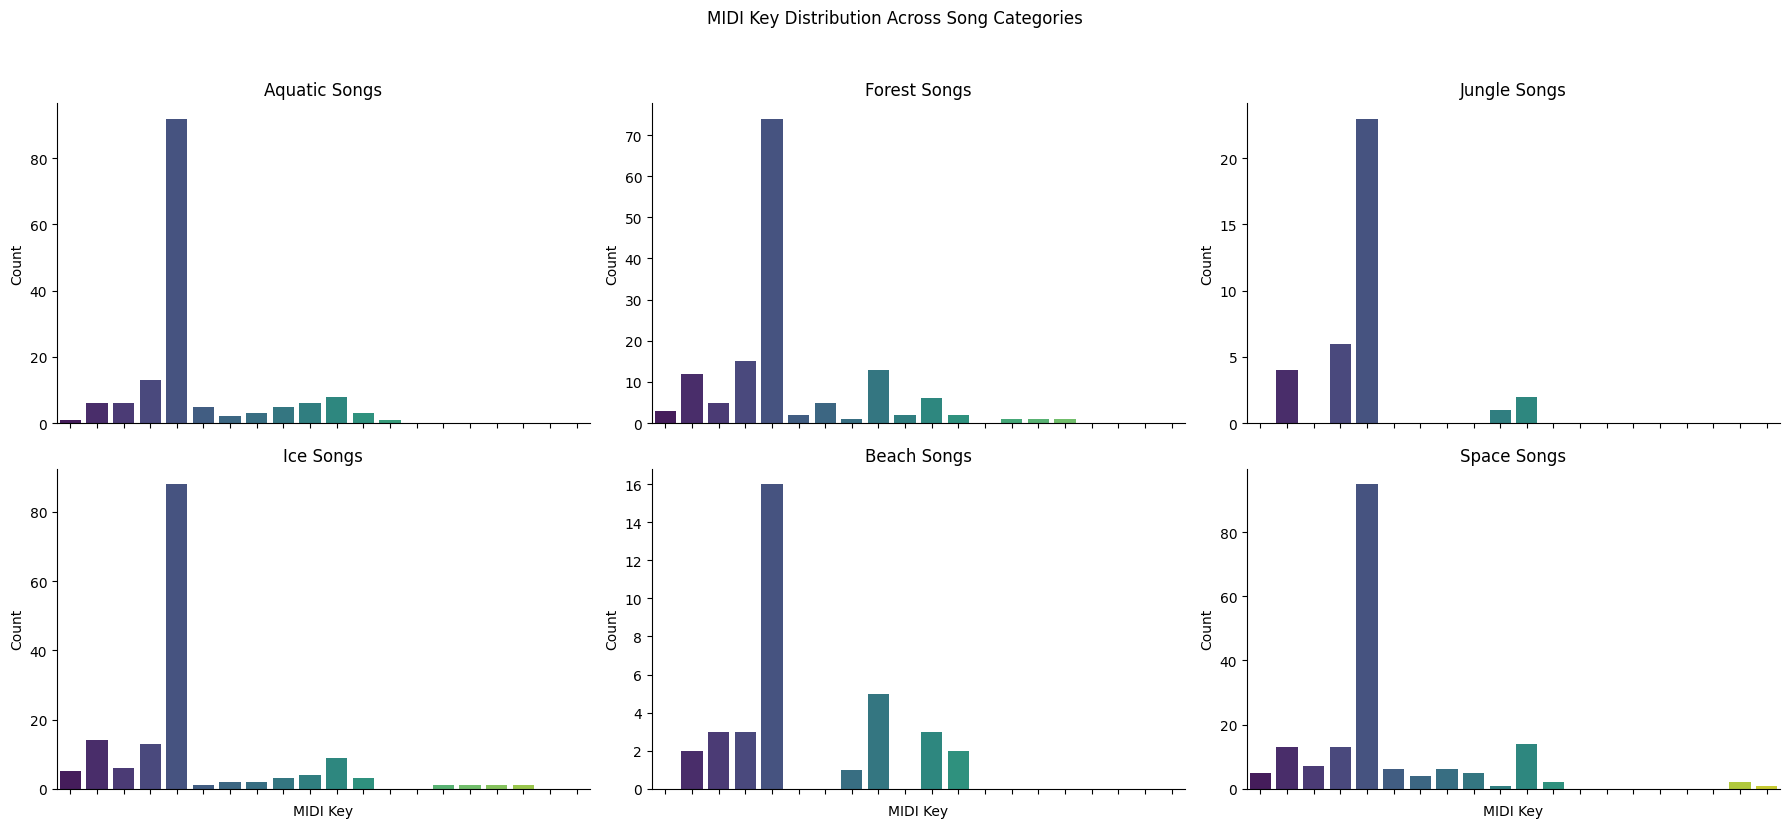

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a faceted bar plot
g = sns.catplot(
    data=midi_key_distributions_df,
    x='midi_key',
    y='count',
    col='category',
    kind='bar',
    col_wrap=3, # Wrap columns after 3 plots
    height=4, aspect=1.5, # Adjust size of each facet
    hue='midi_key', # Assign hue to midi_key for palette to work without warning
    palette='viridis', # Choose a color palette
    sharey=False, # Allow y-axis to scale independently for each facet
    legend=False # Suppress the legend as colors are directly mapped to x-axis
)

# Set the title of the overall plot
g.fig.suptitle('MIDI Key Distribution Across Song Categories', y=1.03) # Adjust y to prevent overlap with titles

# Rotate x-axis labels for better readability
g.set_xticklabels(rotation=45, ha='right')

# Set individual subplot titles
for ax in g.axes.flat:
    ax.set_title(ax.get_title().replace('category = ', ''))
    ax.set_xlabel('MIDI Key')
    ax.set_ylabel('Count')

# Adjust the layout to prevent labels from overlapping
plt.tight_layout()
plt.show()

In [ ]:
from pyspark.sql.functions import avg

avg_bpm_df_new = all_songs_df.groupBy('category').agg(avg('midi_bpm').alias('Average BPM')).toPandas()

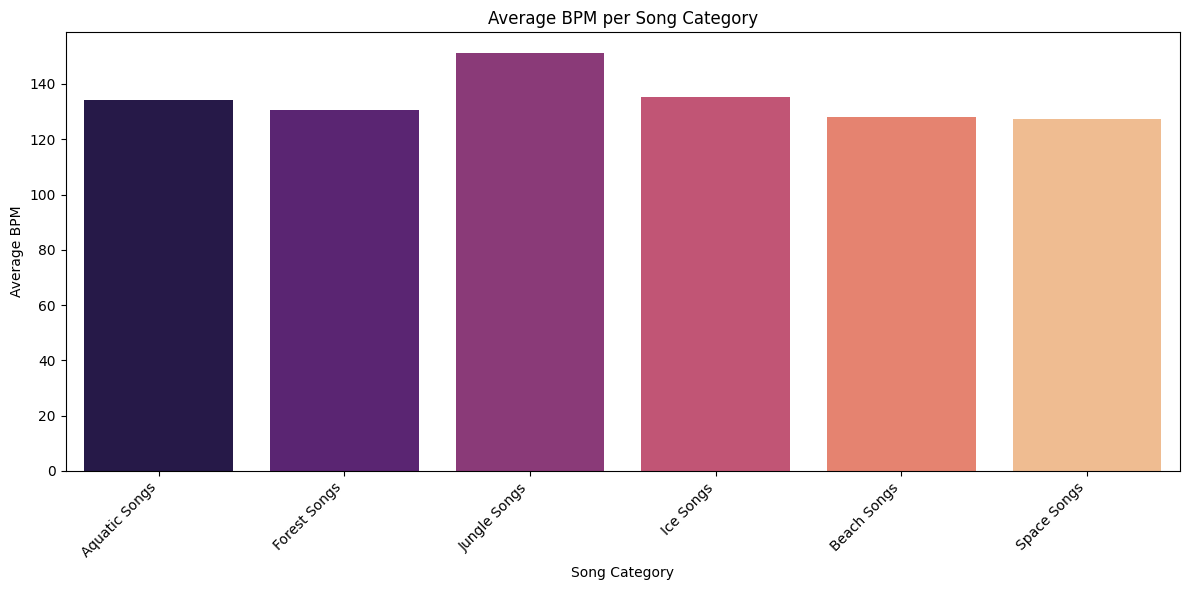

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x='category', y='Average BPM', data=avg_bpm_df_new, palette='magma', hue='category', legend=False)
plt.title('Average BPM per Song Category')
plt.xlabel('Song Category')
plt.ylabel('Average BPM')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Correlation

In [ ]:
from pyspark.sql.functions import avg

new_pivot_table = all_songs_df.groupBy('midi_key') \
                               .pivot('console') \
                               .agg(avg('midi_bpm'))

new_pivot_table = new_pivot_table.dropna()

print("New Pivot Table: Average MIDI BPM by Key and Console (with nulls removed)")
new_pivot_table.show(truncate=False)
print(f"Total count of new_pivot_table: {new_pivot_table.count()}")

New Pivot Table: Average MIDI BPM by Key and Console (with nulls removed)
+--------+----+---+---+---------+---+-------+--------+--------+---+-------+------+---+------+------------+---+---+---+---+------+------+----+----+---+----+----+-------+
|midi_key|2600|32x|3ds|dreamcast|ds |gameboy|gamecube|gamegear|gba|genesis|master|n64|neogeo|neogeopocket|nes|ps1|ps2|ps4|saturn|segacd|snes|tg16|wii|wiiu|xbox|xbox360|
+--------+----+---+---+---------+---+-------+--------+--------+---+-------+------+---+------+------------+---+---+---+---+------+------+----+----+---+----+----+-------+
+--------+----+---+---+---------+---+-------+--------+--------+---+-------+------+---+------+------------+---+---+---+---+------+------+----+----+---+----+----+-------+

Total count of new_pivot_table: 0


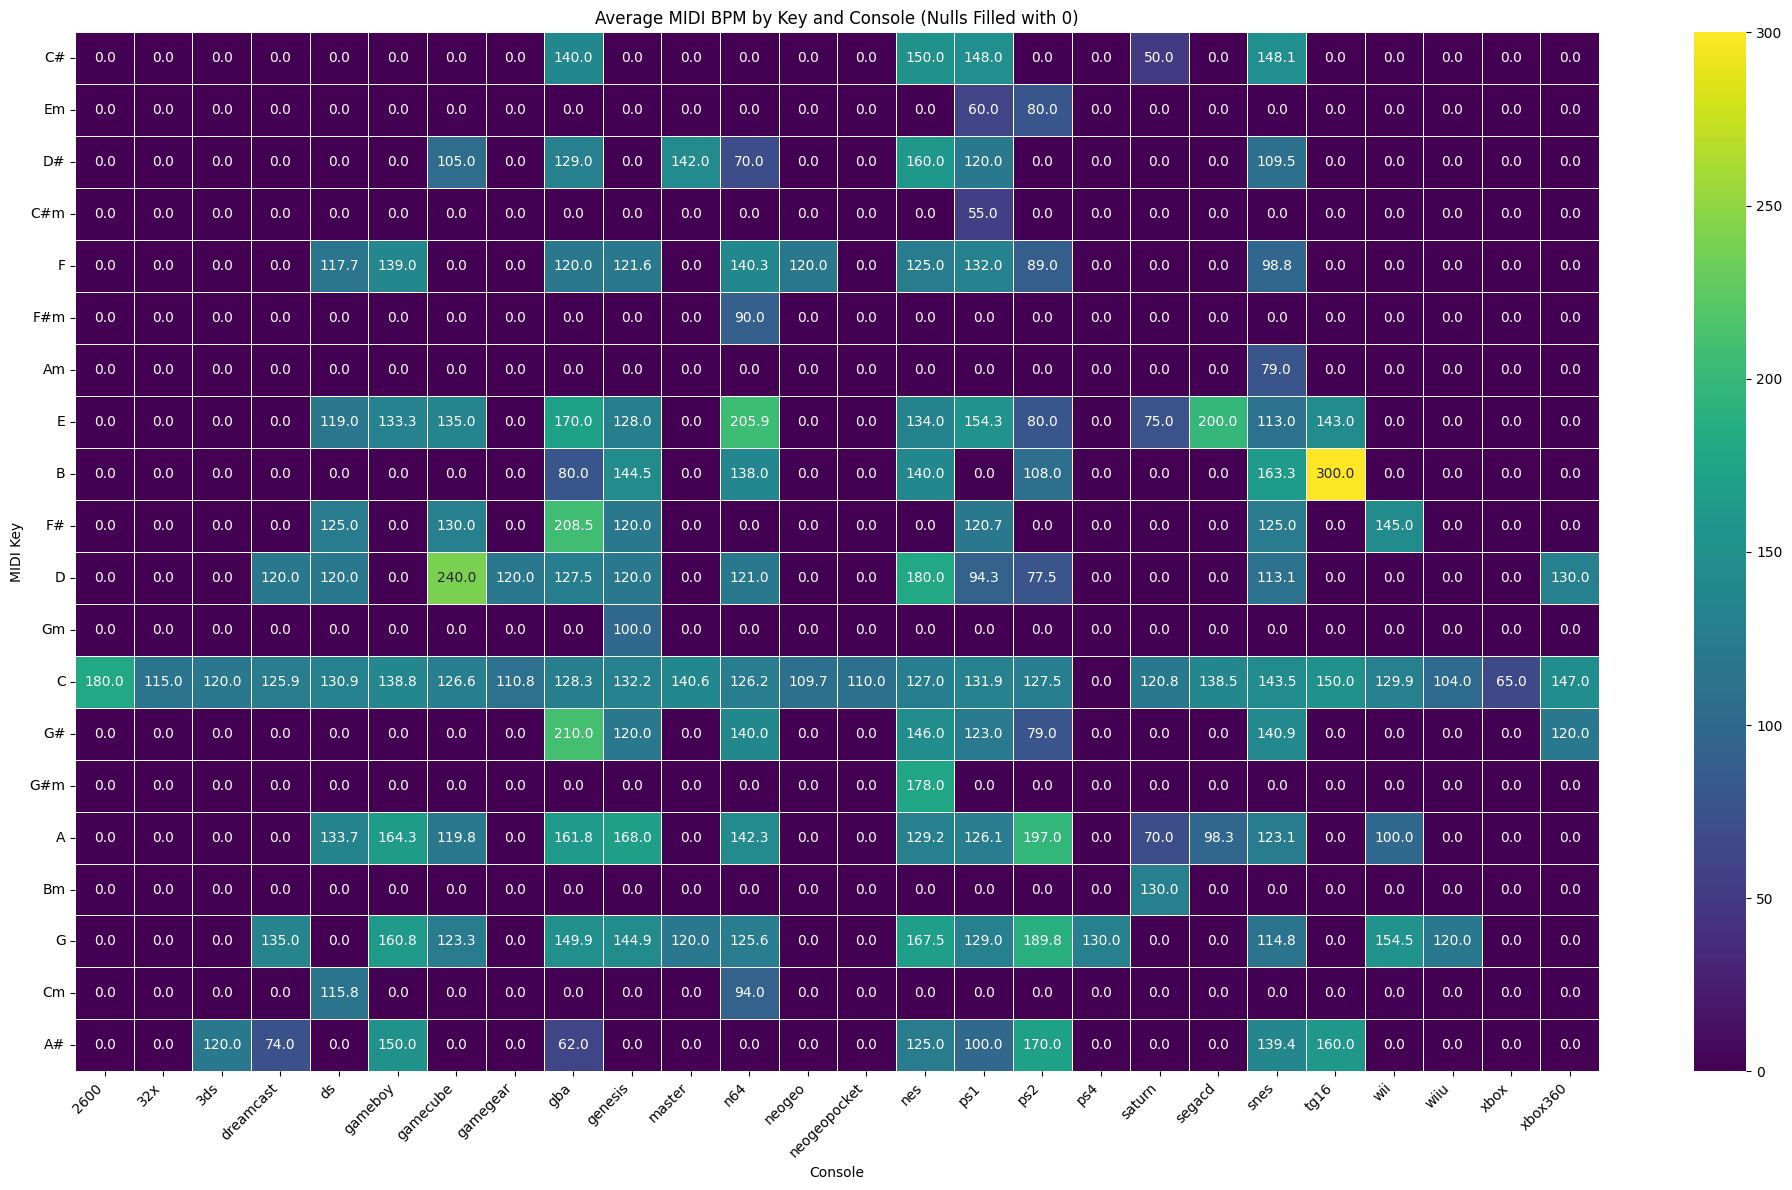

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import avg

# 1. Recreate the Spark pivot table
new_pivot_table_filled = all_songs_df.groupBy('midi_key') \
                                   .pivot('console') \
                                   .agg(avg('midi_bpm'))

# 2. Fill any null values with 0
new_pivot_table_filled = new_pivot_table_filled.fillna(0)

# 3. Convert the modified Spark DataFrame to a Pandas DataFrame
new_pivot_table_pandas_filled = new_pivot_table_filled.toPandas()

# 4. Set the midi_key column as the index of the Pandas DataFrame
new_pivot_table_pandas_filled = new_pivot_table_pandas_filled.set_index('midi_key')

# 5. Create a heatmap
plt.figure(figsize=(20, 12)) # Adjusted figure size for better readability
sns.heatmap(new_pivot_table_pandas_filled, annot=True, cmap='viridis', fmt=".1f", linewidths=.5)
plt.title('Average MIDI BPM by Key and Console (Nulls Filled with 0)')
plt.xlabel('Console')
plt.ylabel('MIDI Key')

# 6. Adjust x-axis labels rotation for readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# 7. Display the plot
plt.tight_layout()
plt.show()

Machine Learning

In [ ]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml import Pipeline

In [ ]:
from pyspark.sql.functions import col

# 2. Select the relevant columns and drop null values
selected_df = all_songs_df.select("midi_key", "midi_bpm", "category").na.drop()

# 3. Create a StringIndexer for 'midi_key'
string_indexer = StringIndexer(inputCol="midi_key", outputCol="midi_key_index")

# 4. Instantiate a OneHotEncoderEstimator for 'midi_key_index'
one_hot_encoder = OneHotEncoder(inputCol="midi_key_index", outputCol="midi_key_onehot", dropLast=False)

# 5. Create a VectorAssembler to combine 'midi_bpm' and 'midi_key_onehot'
vector_assembler = VectorAssembler(inputCols=["midi_bpm", "midi_key_onehot"], outputCol="features_unscaled")

# 6. Instantiate a StandardScaler to scale the 'features_unscaled' vector
scaler = StandardScaler(inputCol="features_unscaled", outputCol="scaled_features", withStd=True, withMean=True)

# 7. Create a Spark ML Pipeline
pipeline = Pipeline(stages=[string_indexer, one_hot_encoder, vector_assembler, scaler])

# 8. Fit the pipeline to the processed DataFrame and transform the data
model = pipeline.fit(selected_df)
ml_data_spark = model.transform(selected_df)

# 9. Convert the ml_data_spark DataFrame to a Pandas DataFrame
ml_data_pandas = ml_data_spark.select("scaled_features", "category").toPandas()

print("ML data prepared in Spark and converted to Pandas DataFrame.")
print("First 5 rows of ml_data_pandas:")
print(ml_data_pandas.head())

Selected DataFrame count after dropping nulls: 693
ML data prepared in Spark and converted to Pandas DataFrame.
First 5 rows of ml_data_pandas:
                                     scaled_features       category
0  [-0.25656412052538596, 0.8859729996349646, -0....  Aquatic Songs
1  [-0.05306526858488993, -1.1270738487159548, -0...  Aquatic Songs
2  [2.3888865638077714, -1.1270738487159548, -0.3...  Aquatic Songs
3  [-0.6645735060458808, 0.8859729996349646, -0.3...  Aquatic Songs
4  [0.1504311413986856, -1.1270738487159548, -0.3...  Aquatic Songs


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import pandas as pd

ml_data_pandas['features'] = ml_data_pandas['scaled_features'].apply(lambda x: x.toArray() if hasattr(x, 'toArray') else x)

# Separate features (X) and target (y)
X = pd.DataFrame(ml_data_pandas['features'].tolist())
y = ml_data_pandas['category']

# Encode target variable if it's categorical strings
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("RandomForestClassifier model trained.")

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
class_report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"\nModel Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(class_report)
print("\nConfusion Matrix:")
print(conf_matrix)


Training set size: 485
Test set size: 208
RandomForestClassifier model trained.

Model Accuracy: 0.2019

Classification Report:
               precision    recall  f1-score   support

Aquatic Songs       0.12      0.09      0.10        55
  Beach Songs       0.12      0.09      0.11        11
 Forest Songs       0.30      0.25      0.27        40
    Ice Songs       0.21      0.33      0.25        40
 Jungle Songs       0.00      0.00      0.00        13
  Space Songs       0.24      0.27      0.25        49

     accuracy                           0.20       208
    macro avg       0.17      0.17      0.16       208
 weighted avg       0.19      0.20      0.19       208


Confusion Matrix:
[[ 5  3  9 19  4 15]
 [ 2  1  2  3  2  1]
 [ 9  2 10  9  1  9]
 [10  1  4 13  0 12]
 [ 1  0  1  6  0  5]
 [14  1  7 12  2 13]]


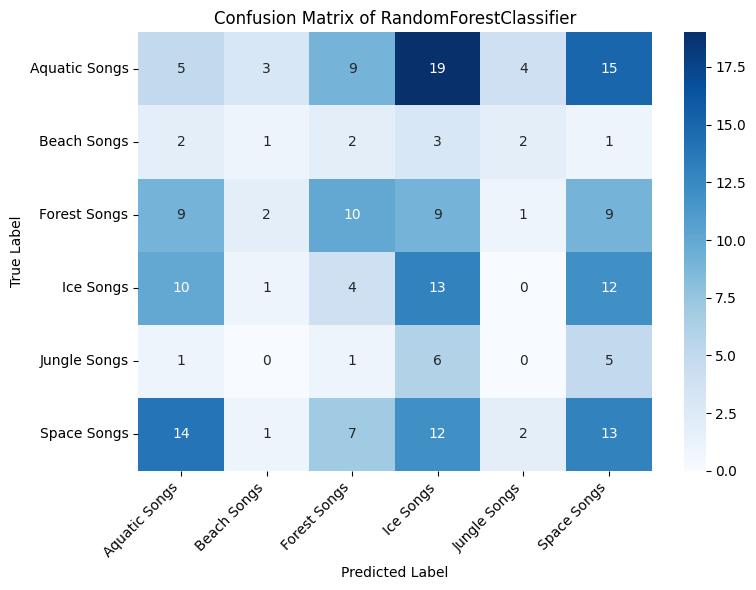

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'label_encoder' not in locals():
    from sklearn.preprocessing import LabelEncoder
    y = ml_data_pandas['category'] # ml_data_pandas is available
    label_encoder = LabelEncoder()
    label_encoder.fit(y)

class_names = label_encoder.classes_

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix of RandomForestClassifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()